In [220]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

import numpy as np
import scipy
import copy

from scipy.sparse import coo_matrix, block_diag, identity, hstack, csr_matrix, csc_matrix, vstack
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import time 

from pyiga import assemble, bspline, vform, geometry, vis, solvers, utils, topology, ieti, algebra, operators, adaptive
from pyiga import algebra_cy, ieti_cy, bspline_cy

from scipy.sparse.linalg import aslinearoperator as LinOp

np.set_printoptions(linewidth=100000)
np.set_printoptions(precision=5)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [221]:
def Lshape(deg, N, k=1):
    kvs = [2 * (bspline.make_knots(deg, 0.0, 1.0, N, mult=k),),2 * (bspline.make_knots(deg, 0.0, 1.0, N, mult=k),)]

    # define geometry
    geos = [
        geometry.Quad(np.array([[-1,-1],[0,-1],[-1,1],[0,0]]).T),
        geometry.Quad(np.array([[-1,1],[0,0],[1,1],[1,0]]).T)
    ]

    patches = [(k, g) for k, g in zip(kvs,geos)]
    M = topology.MultiPatch(patches)
    return M

In [222]:
def cart2pol(x, y):
    r = np.sqrt(x**2 + y**2)
    phi = np.arctan2(y, x)
    return(r, phi%(2*np.pi))
def u(x,y):
    r, phi = cart2pol(x,y)
    return r**(2/3)*np.sin(2*phi/3)
def ux(x,y):
    r, phi = cart2pol(x,y)
    return -2./3*r**(-1./3)*np.sin(phi/3)
def uy(x,y):
    r, phi = cart2pol(x,y)
    return 2./3*r**(-1./3)*np.cos(phi/3)

In [8]:
degs = (5,)
maxpatches =(1500,1500,1500,1300,1200,1200)
level = (2,2,2,2,2,2)
maxiter=1

direct=False

prim = {'v':1, 'e':0}
#R = np.zeros((max(maxiters),4*len(degs)+1))

example=1

if example==0:
    f=0
    g=u
else:
    f=1
    g=0

plot=1
dir_data={0:g}
U=[]
eta=[]
# L2err = []
# Eerr = []

for i,deg in enumerate(degs):
    N = 2*deg+1
    M = Lshape(deg,N,1)

    #fixed_corner = (2,0,0)
    IMap = ieti.IetiMapper(M, dir_data=dir_data, subspace='C0', elim=1)
    
    k=0
    while k < maxiter:
        # if plot:
        #     M.plotmesh(figsize=(10,10), knots=1, nodes=30, bwidth=0.01, patch_idx=1)
        #     plt.axis('off');
        #     plt.axis('scaled');
        #     #plt.savefig('/home/wolfman/Pictures/Lshape/p'+str(deg)+'/i'+str(k)+'.pdf',bbox_inches='tight');
        #     plt.show();
        #     plt.close();

        ### SOLVE
        A, RHS = IMap.assemble(a=1,f=f, M=None)
        N = [A.shape[0] for A in A]
            
        Prim = csc_matrix((IMap.nLocDofs,0))

        if bool(prim['v']):
            PrimV, to_be_eliminated = IMap.nodes_as_primals(dir_boundary=False)
            Prim = scipy.sparse.hstack([Prim, PrimV])
        if bool(prim['e']):
            Prim = scipy.sparse.hstack([Prim, IMap.interface_averages_as_primals(1)])

        B, eliminated_constraints = IMap.ConstraintMatrices(eliminate=to_be_eliminated)
        SD = ieti.ScaledDirichletPreconditioner(A, B, IMap)

        nPrim=Prim.shape[1]
        print(nPrim)

        if nPrim==0:
            I = ieti.IetiSystem(A, B, RHS, N)
            F, b = I.SchurComplement(), I.RHSforSchurComplement()
            C = [scipy.sparse.csr_matrix((0,A[p].shape[1])) for p in range(len(B))]
        else:
            primal = ieti.PrimalSystem(Prim)
            modA, modB, modRHS, C = primal.incorporate_PrimalConstraints(A, B, RHS, IMap)
    
            loc_solver = primal.compute_PrimalBasis(modA, modB, modRHS, C)
            
            modA.append(primal.A_prim), modB.append(primal.B_prim), modRHS.append(primal.RHS_prim)
            loc_solver.append(solvers.make_solver(primal.A_prim, spd=True, symm=True)), N.append(primal.A_prim.shape[0])
            
            I = ieti.IetiSystem(modA, modB, modRHS, N, loc_solver)
            F, b = I.SchurComplement(), I.RHSforSchurComplement()

        SD.setupSelectionScaling()
        Prec1 = SD.AsOperator()
        lam, it, min_eig, max_eig, r = solvers.pcg(F, b, x0=None, maxiter=2000, P=Prec1, output=1, rtol=1e-6, atol=1e-12)
        
        #R[k,1 + 4*i] = it
        #R[k,2 + 4*i] = abs(max_eig/min_eig)

        # Prec2=ieti.EdgePreconditioner(IMap, SD.S_dense, SD.B ,C)
        # lam, it, min_eig, max_eig, r = solvers.pcg(F, b, x0=None, maxiter=2000, P=Prec2, output=1, rtol=1e-6, atol=1e-12)

        # R[k,3 + 4*i] = it
        # R[k,4 + 4*i] = abs(max_eig/min_eig)

        uh = I.constructSolutionFromLagrangeMultipliers(lam)
        if nPrim>0:
            uh = primal.distributePrimalSolution(uh)
        uh = np.concatenate(IMap.completeDirichlet(uh))

        # U.append(u)

        # dir_bcs = IMap.set_fixed_boundary(dir_data, local=False)
        # Mh = IMap.assemble_volume("u * v * dx", arity=2, domain_id=0)
        # Kh = IMap.assemble_volume("inner(grad(u),grad(v)) * dx", arity=2, domain_id=0)
        # Fh = IMap.assemble_volume("(f * v) * dx", arity=1, domain_id=0, f=f)
        # LS = assemble.RestrictedLinearSystem(Kh, Fh, dir_bcs)
        # uh = LS.complete(solvers.make_solver(LS.A, spd=True)@LS.b)

        # u_load = IMap.assemble_volume("(f * v) * dx", arity=1, domain_id=0, f=u)
        # u_exact = operators.make_solver(Mh,spd=True)@u_load
        # eh = u_exact-uh
        # U.append(uh)

        # L2err = np.sqrt(eh.T@Mh@eh)
        # Eerr = np.sqrt(eh.T@Kh@eh)

        if plot:
            IMap.plot(uh,mesh=True)
            plt.show()

        err_ind=adaptive.mp_resPois(IMap, uh, nu=1, f=f)
        eta.append(np.linalg.norm(err_ind))
        #print(eta[-1]/Eerr)

        print("Error Estimator: {:.3}".format(eta[-1]))
        marked_patches = adaptive.doerfler_mark(err_ind, theta=0.8, TOL=0.01)
        marked_patches = {p:None for p in marked_patches}

        # if IMap.nPatches + 3*len(marked_patches) >= maxpatches[i]:
        #     break;

        # P = IMap.h_refine(h_ref=marked_patches,ref="rs", return_P = True, in_subspace=True)
        # for m in range(len(U)):
        #     U[m] = P@U[m]

        k+=1
        print("#####################################################")
    P = IMap.h_refine(h_ref=-1,ref="rs", return_P = True, in_subspace=True)
    P = IMap.p_refine(return_P = True, in_subspace=True)@P

    L2err = np.zeros(len(U))
    Eerr = np.zeros(len(U))
    
    Mh = IMap.assemble_volume("u * v * dx", arity=2, domain_id=0)
    Kh = IMap.assemble_volume("inner(grad(u),grad(v)) * dx", arity=2, domain_id=0)

    u_load = IMap.assemble_volume("(f * v) * dx", arity=1, domain_id=0, f=u)
    u_exact = operators.make_solver(Mh,spd=True)@u_load

    for m in range(len(U)):
        eh = u_exact - P@U[m] 

        L2err[m]= np.sqrt(eh.T@Mh@eh)
        Eerr[m] = np.sqrt(eh.T@Kh@eh)

setting up constraints took 0.0017011165618896484 seconds.
Basis setup took 0.001477956771850586 seconds


ValueError: Buffer dtype mismatch, expected 'double' but got 'int'

In [223]:
M = Lshape(2,4,1)
M.h_refine()
M.h_refine({1:-1,2:-1,3:-1,7:-1})
dir_data={0:0}
f=0

In [224]:
IMap = ieti.IetiMapper(M, dir_data=dir_data, subspace='C0', elim=1)

setting up constraints took 0.024279117584228516 seconds.
Basis setup took 0.0039212703704833984 seconds


In [225]:
A, RHS = IMap.assemble(a=1,f=f, M=None)
N = [A.shape[0] for A in A]
            
Prim = csc_matrix((IMap.nLocDofs,0))

IndexError: index 92 is out of bounds for axis 0 with size 92

In [52]:
PrimV = IMap.nodes_as_primals(dir_boundary=False)

In [54]:
primal = ieti.PrimalSystem(PrimV)

In [56]:
B, eliminated_constraints = IMap.ConstraintMatrices()

In [58]:
modA, modB, modRHS, C = primal.incorporate_PrimalConstraints(A, B, RHS, IMap)

In [59]:
modA

[<Compressed Sparse Row sparse array of dtype 'float64'
 	with 14 stored elements and shape (5, 5)>,
 <Compressed Sparse Row sparse array of dtype 'float64'
 	with 26 stored elements and shape (7, 7)>,
 <Compressed Sparse Row sparse array of dtype 'float64'
 	with 10 stored elements and shape (5, 5)>,
 <Compressed Sparse Row sparse array of dtype 'float64'
 	with 26 stored elements and shape (7, 7)>,
 <Compressed Sparse Row sparse array of dtype 'float64'
 	with 28 stored elements and shape (7, 7)>,
 <Compressed Sparse Row sparse array of dtype 'float64'
 	with 28 stored elements and shape (7, 7)>,
 <Compressed Sparse Row sparse array of dtype 'float64'
 	with 12 stored elements and shape (4, 4)>,
 <Compressed Sparse Row sparse array of dtype 'float64'
 	with 14 stored elements and shape (5, 5)>]

In [60]:
A

[<Compressed Sparse Row sparse matrix of dtype 'float64'
 	with 12 stored elements and shape (4, 4)>,
 <Compressed Sparse Row sparse matrix of dtype 'float64'
 	with 24 stored elements and shape (6, 6)>,
 <Compressed Sparse Row sparse matrix of dtype 'float64'
 	with 8 stored elements and shape (4, 4)>,
 <Compressed Sparse Row sparse matrix of dtype 'float64'
 	with 24 stored elements and shape (6, 6)>,
 <Compressed Sparse Row sparse matrix of dtype 'float64'
 	with 26 stored elements and shape (6, 6)>,
 <Compressed Sparse Row sparse matrix of dtype 'float64'
 	with 26 stored elements and shape (6, 6)>,
 <Compressed Sparse Row sparse matrix of dtype 'float64'
 	with 12 stored elements and shape (4, 4)>,
 <Compressed Sparse Row sparse matrix of dtype 'float64'
 	with 12 stored elements and shape (4, 4)>]

In [5]:
IMap = assemble.MultiBasis(M, subspace='C0', elim=True)

setting up constraints took 0.0023512840270996094 seconds.
Basis setup took 0.0022008419036865234 seconds


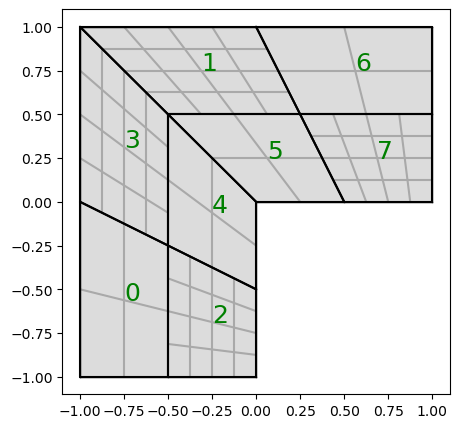

In [132]:
M.plotmesh(knots=1,patch_idx=1)